### Solution: Set up Hugging Face API Token

1.  **Create a Hugging Face Account and Token**: If you don't have one, sign up at [huggingface.co](https://huggingface.co/). Then, go to your profile settings -> `Access Tokens` and generate a new token with at least `read` access.
2.  **Add Token to Colab Secrets**: In Google Colab, click the "🔑" icon in the left sidebar to open the "Secrets" panel. Add a new secret named `HF_TOKEN` and paste your Hugging Face API token as its value. Make sure to enable "Notebook access" for this secret.
3.  **Load the Token**: Run the following code cell to load your `HF_TOKEN` from Colab secrets and set it as an environment variable. This will allow `transformers` library functions to use your token for authentication.

After running the above cell, you should re-run the previous cell (`yCAuhpwT0E5A`). The `AutoTokenizer.from_pretrained` and `AutoModelForTokenClassification.from_pretrained` methods will automatically pick up the `HF_TOKEN` environment variable, and the warning message should no longer appear.

In [ ]:
from google.colab import userdata
import os

# Load the HF_TOKEN from Colab secrets
hf_token = userdata.get('HF_TOKEN')

# Set it as an environment variable
os.environ['HF_TOKEN'] = hf_token

print("Hugging Face token loaded from secrets and set as environment variable.")
print("You can now re-run the previous cell to use the authenticated requests.")

Hugging Face token loaded from secrets and set as environment variable.
You can now re-run the previous cell to use the authenticated requests.


## Methodology

The project followed a comprehensive methodology to fine-tune the IndicBERTv2 model for Assamese NLP tasks, encompassing data preparation, model training, and evaluation. The core framework utilized was Hugging Face's Transformers library, leveraging its pre-trained models and fine-tuning capabilities.

### 1. Environment Setup and Dependencies

Initial steps involved setting up the Google Colab environment, installing necessary Python libraries (`transformers`, `datasets`, `accelerate`, `seqeval`, `sentencepiece`, `evaluate`, `scikit-learn`, `matplotlib`, `seaborn`), and configuring access to Hugging Face by securely loading an `HF_TOKEN` from Colab secrets.

### 2. Data Preparation and Alignment

Custom Assamese datasets for NER, POS, and Sentiment Analysis were uploaded as `sentences.txt`, `NER.csv`, and `POS.json` files. A critical step was the alignment of tokens and labels for NER and POS tasks:

-   **NER Data**: `NER.csv` contained token-tag pairs, with empty lines separating sentences. This was parsed into a list of dictionaries, each containing `tokens` and `ner_tags`.
-   **POS Data**: `POS.json` provided sentence-level POS tags. This data was processed to create a mapping from sentence to POS tags.
-   **Alignment**: A custom script aligned the `NER.csv` and `POS.json` data, ensuring that tokens and their corresponding NER and POS tags were correctly matched. Sentences without corresponding POS data were removed to maintain data integrity. A key helper function `align_labels_with_tokens` was implemented to align word-level labels with the subword tokens generated by the tokenizer, handling special tokens and propagating labels for multi-subword tokens.
-   **Sentiment Data**: An Assamese sentiment JSON file was uploaded, converted to a Pandas DataFrame, and numerical labels (0: Negative, 1: Neutral, 2: Positive) were assigned.

### 3. Tokenization and Dataset Creation

The `ai4bharat/IndicBERTv2-MLM-only` model checkpoint was chosen for all tasks. The `AutoTokenizer` was loaded with `keep_accents=True` to preserve Assamese vowel matras, which are crucial for the language's phonetics. Custom `tokenize_and_align_labels_ner` and `tokenize_and_align_labels_pos` functions were developed to tokenize input sentences and align the generated subword tokens with their respective NER and POS labels, handling the `-100` padding for special tokens.

Hugging Face's `Dataset` object was used to manage the data. The aligned data for NER and POS, and the processed sentiment data, were converted into `Dataset` objects and then tokenized. Each dataset was split into 80% training and 20% testing (or 60/20/20 for sentiment analysis) subsets using `train_test_split`.

### 4. Model Fine-tuning

Separate `AutoModelForTokenClassification` models were fine-tuned for NER and POS, and an `AutoModelForSequenceClassification` for Sentiment Analysis. The `AutoModelForMaskedLM` was used directly for the MLM task.

-   **NER and POS Models**: Initialized with `num_labels` based on the unique tag sets (`label_list_ner`, `label_list_pos`) and configured with `id2label` and `label2id` mappings. `DataCollatorForTokenClassification` was used for dynamic padding. Training arguments (`TrainingArguments`) specified parameters like `output_dir`, `eval_strategy`, `learning_rate`, `batch_size`, `num_train_epochs`, and `fp16` for efficient GPU training. `Trainer` objects were then used to execute the fine-tuning process.
-   **Sentiment Analysis Model**: Similar to NER/POS, this model was initialized with `num_labels` and label mappings. The `compute_metrics` function, utilizing `evaluate` library for accuracy, precision, recall, and F1-score, was passed to the `Trainer` for evaluation during training.
-   **Masked Language Modeling (MLM)**: For this task, the `AutoModelForMaskedLM` was loaded directly. A `pipeline` was created to allow interactive prediction of masked tokens.

### 5. Interactive Inference

After training, interactive inference cells were provided for each task:

-   **NER/POS**: A `pipeline` with `token-classification` was used to load the fine-tuned models. Users could input sentences and receive dataframes showing token, predicted NER tag, and predicted POS tag.
-   **MLM**: A `fill-mask` pipeline allowed users to input sentences with `[MASK]` tokens, and the model predicted the top 5 most probable replacement tokens.
-   **Sentiment Analysis**: A `text-classification` pipeline loaded the fine-tuned sentiment model, allowing users to input Assamese sentences and receive predicted sentiment labels and confidence scores.

### 6. Model Evaluation

Dedicated evaluation cells were included for NER, POS, and Sentiment Analysis:

-   **NER/POS Evaluation**: Metrics such as accuracy, precision, recall, and F1-score were computed using `sklearn.metrics.precision_recall_fscore_support` and `accuracy_score` on a small mock test dataset. The results were displayed and visualized using bar plots.
-   **Sentiment Analysis Evaluation**: The `sentiment_trainer.evaluate` function was used to calculate metrics on the test dataset. A detailed classification report and a confusion matrix were generated and visualized using `matplotlib` and `seaborn`.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from google.colab import files
from datasets import Dataset

# ==========================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# ==========================================
# This downloads the core Transformer code frameworks (~600 MB)
!pip install -q transformers datasets accelerate seqeval sentencepiece

# We use ai4bharat's IndicBERT v2, which handles Assamese brilliantly
model_checkpoint = "ai4bharat/IndicBERTv2-MLM-only"
print(f"Downloading tokenizer for {model_checkpoint}...")
# keep_accents=True is crucial to keep Assamese vowel matras intact
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, keep_accents=True)

# ==========================================
# HELPER FUNCTION FOR SUBWORD ALIGNMENT
# ==========================================
def align_labels_with_tokens(labels, word_ids):
    new_labels = []
    current_word = None
    for word_id in word_ids:
        if word_id is None:
            new_labels.append(-100)  # PyTorch ignores -100 index during loss calculation
        elif word_id != current_word:
            current_word = word_id
            new_labels.append(labels[word_id])
        else:
            # Propagate the same tag for trailing subwords of the same word
            new_labels.append(labels[word_id])
    return new_labels


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 7.75MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

### Step 2: Upload Your Data Files

Run the cell below to upload your `sentences.txt`, `NER.csv`, and `POS.json` files. You will be prompted to select each file separately.

In [ ]:
from google.colab import files
import json

# 1. Upload sentences.txt
print("Please upload your 'sentences.txt' file (containing raw sentences, one per line):")
uploaded_sentences = files.upload()
sentences_file_name = list(uploaded_sentences.keys())[0]

# Assuming sentences.txt contains one sentence per line
raw_sentences_list = uploaded_sentences[sentences_file_name].decode("utf-8").strip().splitlines()

# 2. Upload NER.csv
print("\nPlease upload your 'NER.csv' file (token\\tNER_tag, empty line separates sentences):")
uploaded_ner = files.upload()
ner_file_name = list(uploaded_ner.keys())[0]
raw_ner_data = uploaded_ner[ner_file_name].decode("utf-8")

# 3. Upload POS.json
print("\nPlease upload your 'POS.json' file (JSON array of objects with 'sentence' and 'tags'):")
uploaded_pos = files.upload()
pos_file_name = list(uploaded_pos.keys())[0]
raw_pos_data = uploaded_pos[pos_file_name].decode("utf-8")

print("\nAll files uploaded successfully! Now parsing and aligning data...")

# --------------------------------------------------
# Parse NER.csv Data
# --------------------------------------------------
ner_parsed_data = []
current_tokens = []
current_ner_tags = []
all_unique_ner_tags = set()

for line in raw_ner_data.splitlines():
    line = line.strip()

    if line:
        parts = line.split('\t')

        if len(parts) == 2:
            token, tag = parts
            current_tokens.append(token)
            current_ner_tags.append(tag)
            all_unique_ner_tags.add(tag)
        else:
            print(f"Warning: Skipping malformed line in NER CSV: {line}")

    else:
        if current_tokens:
            ner_parsed_data.append({
                "tokens": list(current_tokens),
                "ner_tags": list(current_ner_tags)
            })

        current_tokens = []
        current_ner_tags = []

# Add last sentence if file doesn't end with blank line
if current_tokens:
    ner_parsed_data.append({
        "tokens": list(current_tokens),
        "ner_tags": list(current_ner_tags)
    })

# --------------------------------------------------
# Parse POS.json Data
# --------------------------------------------------
pos_json_list = json.loads(raw_pos_data)

all_unique_pos_tags = set()

# Map sentence -> POS dictionary
pos_map_by_sentence = {
    entry["sentence"].strip(): entry["tags"]
    for entry in pos_json_list
}

for entry in pos_json_list:
    for tag in entry["tags"].values():
        all_unique_pos_tags.add(tag)

# --------------------------------------------------
# Align NER and POS Data
# --------------------------------------------------
aligned_data = []
removed_sentences = 0

for idx, ner_entry in enumerate(ner_parsed_data):

    tokens = ner_entry["tokens"]
    ner_tags = ner_entry["ner_tags"]

    # Reconstruct sentence exactly as in POS.json
    reconstructed_sentence = " ".join(tokens)

    # Remove sentence if no matching POS data exists
    if reconstructed_sentence not in pos_map_by_sentence:
        print(f"Removed sentence (no POS match): '{reconstructed_sentence[:80]}...'")
        removed_sentences += 1
        continue

    current_pos_map = pos_map_by_sentence[reconstructed_sentence]

    # Assign POS tag for each token (default "O" if token missing)
    pos_tags = [
        current_pos_map.get(token, "O")
        for token in tokens
    ]

    aligned_data.append({
        "tokens": tokens,
        "ner_tags": ner_tags,
        "pos_tags": pos_tags
    })

# --------------------------------------------------
# Summary
# --------------------------------------------------
print("\n========== SUMMARY ==========")
print(f"Total NER sentences      : {len(ner_parsed_data)}")
print(f"Successfully aligned     : {len(aligned_data)}")
print(f"Removed (no POS match)   : {removed_sentences}")

if aligned_data:
    print("\nFirst aligned entry:")
    print(aligned_data[0])


Please upload your 'sentences.txt' file (containing raw sentences, one per line):


Saving sentences2.txt to sentences2 (2).txt

Please upload your 'NER.csv' file (token\tNER_tag, empty line separates sentences):


Saving ner3.csv to ner3 (1).csv

Please upload your 'POS.json' file (JSON array of objects with 'sentence' and 'tags'):


Saving pos2.json to pos2 (1).json

All files uploaded successfully! Now parsing and aligning data...
Removed sentence (no POS match): 'অনিলে কোৱা মনত নাই ? তাত দপুৰীয়াৰ আহাৰৰ বাবে আমালৈ অপেক্ষা কৰি আছিল ডা: হেৰী প্য...'
Removed sentence (no POS match): 'আৰু হায়দৰাবাদৰ বিৰিয়ানিৰ কথা ক'বই নালাগে ! ইয়াৰ পাছত জগৎপতি গৰুড়ধ্বজ নামৰ কোনো...'
Removed sentence (no POS match): 'আৰু সেই যে অৰ্জুনৰ তপস্যা , ৯৫ ফুট দীঘল ৪৩ ফুট উচ্ছতা বৃহৎ শিলাখণ্ডটো ? সেই অৱস্...'
Removed sentence (no POS match): 'কিন্তু কিয় অৰ্থ সুধিছা পলুদা ? বিষ্ণুৰ এক অৱতাৰ হয়গ্ৰীৱক ইয়াত পূজা - অৰ্চনা কৰ...'
Removed sentence (no POS match): 'কিয় কছাৰী ছোৱালী হিড়িম্বাক ইয়াতে বিয়া কৰোৱা নাছিল ? নদী বন্দৰ হিচাপে গুৱাহাটী আ...'
Removed sentence (no POS match): 'ওচৰেপাজৰে বড়ো মানুহৰ গাঁও আছে চুভী ! জলফিন নোজ বিশাখাপট্টনমৰ অতি বিখ্যাত আৰু চি...'
Removed sentence (no POS match): 'কাম কৰি কেনে পাইছা ৰুকেয়া ? ওমানৰ প্ৰথম হিন্দু ধৰ্মাৱলম্বী লোকসকলে কুচ্চি ভাষা ক...'
Removed sentence (no POS match): 'মনত পৰিল দেৱকান্ত বৰুৱাৰ সাগৰ দে

### Step 3: Prepare and Train the NER Model

Now we will prepare the dataset specifically for Named Entity Recognition (NER) and fine-tune an `AutoModelForTokenClassification` using the uploaded NER annotations. This involves mapping string labels to IDs, tokenizing the input, and aligning the labels to the subword tokens generated by the tokenizer.

In [ ]:
from datasets import Dataset

# Dynamically define label_list for NER from all unique tags found in the dataset
# Ensure 'O' is always first and tags are sorted for consistency
label_list_ner = sorted(list(all_unique_ner_tags - {'O'}))
label_list_ner.insert(0, 'O')

label2id_ner = {l: i for i, l in enumerate(label_list_ner)}
id2label_ner = {i: l for i, l in enumerate(label_list_ner)}

print(f"NER Label List: {label_list_ner}")

def tokenize_and_align_labels_ner(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, ner_tags_example in enumerate(examples["ner_tags"]):
        word_labels_id = []
        for tag in ner_tags_example:
            try:
                word_labels_id.append(label2id_ner[tag])
            except KeyError:
                raise KeyError(
                    f"Tag '{tag}' found in data at example index {i} but not in NER label2id mapping. "
                    f"Available tags: {list(label2id_ner.keys())}. "
                    f"Original sentence tokens: {examples['tokens'][i]}"
                )
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        labels.append(align_labels_with_tokens(word_labels_id, word_ids))
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Convert aligned data into a Hugging Face Dataset format for NER
ner_dataset = Dataset.from_list(aligned_data)

# Run alignment across the dataset and create an 80/20 train/test split
print("Aligning Assamese tokens with subword IDs for NER...")
tokenized_ner_datasets = ner_dataset.map(tokenize_and_align_labels_ner, batched=True)
split_ner_dataset = tokenized_ner_datasets.train_test_split(test_size=0.2)

# --- NER Model Architecture Initialization ---
print("Downloading pre-trained IndicBERT v2 Base model for NER (~1.12 GB)... ")
ner_model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list_ner),
    id2label=id2label_ner,
    label2id=label2id_ner
)

# Set up dynamic padding for batch creation for NER
ner_data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# --- NER Fine-Tuning Execution Configuration ---
# Colab T4 GPU parameters
ner_training_args = TrainingArguments(
    output_dir="./assamese_bert_ner",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=1,
    fp16=True,
    report_to="none"
)

ner_trainer = Trainer(
    model=ner_model,
    args=ner_training_args,
    train_dataset=split_ner_dataset["train"],
    eval_dataset=split_ner_dataset["test"],
    data_collator=ner_data_collator,
)

print("\nNER model initialization complete! Starting fine-tuning loop on GPU...")
ner_trainer.train()
print("\nNER training completed successfully! Model files are saved in './assamese_bert_ner'")

NER Label List: ['O', 'B-DATE', 'B-FAC', 'B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-DATE', 'I-FAC', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER']
Aligning Assamese tokens with subword IDs for NER...


Map:   0%|          | 0/4169 [00:00<?, ? examples/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.12GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,No log,0.250686
2,0.556455,0.188246
3,0.175197,0.177549



NER training completed successfully! Model files are saved in './assamese_bert_ner'


### Step 4: Prepare and Train the POS Model

Similarly, we will now prepare the dataset for Part-of-Speech (POS) tagging and fine-tune another `AutoModelForTokenClassification` using the uploaded POS annotations. This will be a separate model to distinguish between NER and POS tasks.

In [ ]:
# Dynamically define label_list for POS from all unique tags found in the dataset
# Ensure 'O' is always first if present, and tags are sorted for consistency
label_list_pos = sorted(list(all_unique_pos_tags - {'O'}))
# Only insert 'O' if it's not already in the unique tags (it might not be if all tokens have a specific POS tag)
if 'O' in all_unique_pos_tags:
    label_list_pos.insert(0, 'O')
elif 'O' not in label_list_pos:
    # If 'O' wasn't naturally present, but we might have used it as a fallback, add it explicitly.
    # This helps if the align_data step assigned 'O' for missing POS tags.
    label_list_pos.insert(0, 'O')

label2id_pos = {l: i for i, l in enumerate(label_list_pos)}
id2label_pos = {i: l for i, l in enumerate(label_list_pos)}

print(f"POS Label List: {label_list_pos}")

def tokenize_and_align_labels_pos(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, pos_tags_example in enumerate(examples["pos_tags"]):
        word_labels_id = []
        for tag in pos_tags_example:
            try:
                word_labels_id.append(label2id_pos[tag])
            except KeyError:
                raise KeyError(
                    f"Tag '{tag}' found in data at example index {i} but not in POS label2id mapping. "
                    f"Available tags: {list(label2id_pos.keys())}. "
                    f"Original sentence tokens: {examples['tokens'][i]}"
                )
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        labels.append(align_labels_with_tokens(word_labels_id, word_ids))
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Convert aligned data into a Hugging Face Dataset format for POS
pos_dataset = Dataset.from_list(aligned_data)

# Run alignment across the dataset and create an 80/20 train/test split
print("Aligning Assamese tokens with subword IDs for POS...")
tokenized_pos_datasets = pos_dataset.map(tokenize_and_align_labels_pos, batched=True)
split_pos_dataset = tokenized_pos_datasets.train_test_split(test_size=0.2)

# --- POS Model Architecture Initialization ---
print("Downloading pre-trained IndicBERT v2 Base model for POS (~1.12 GB)... ")
pos_model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list_pos),
    id2label=id2label_pos,
    label2id=label2id_pos
)

# Set up dynamic padding for batch creation for POS
pos_data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# --- POS Fine-Tuning Execution Configuration ---
# Colab T4 GPU parameters
pos_training_args = TrainingArguments(
    output_dir="./assamese_bert_pos",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=1,
    fp16=True,
    report_to="none"
)

pos_trainer = Trainer(
    model=pos_model,
    args=pos_training_args,
    train_dataset=split_pos_dataset["train"],
    eval_dataset=split_pos_dataset["test"],
    data_collator=pos_data_collator,
)

print("\nPOS model initialization complete! Starting fine-tuning loop on GPU...")
pos_trainer.train()
print("\nPOS training completed successfully! Model files are saved in './assamese_bert_pos'")

POS Label List: ['O', 'CC_CCD', 'CC_CCS', 'DM_DMD', 'DM_DMI', 'DM_DMQ', 'DM_DMR', 'IN', 'J_JJ', 'J_PJJ', 'J_VJJ', 'N_ANN', 'N_MNN', 'N_NN', 'N_NNP', 'N_NST', 'N_VNN', 'PR_PRF', 'PR_PRI', 'PR_PRL', 'PR_PRP', 'PR_PRQ', 'PSP', 'QT_QTC', 'QT_QTF', 'QT_QTO', 'RB', 'RD_ECH', 'RD_PUNC', 'RD_RDF', 'RD_SYM', 'RP_INJ', 'RP_INTF', 'RP_NEG', 'RP_RPD', 'SUF', 'V_VAUX', 'V_VBI', 'V_VBT', 'V_VM']
Aligning Assamese tokens with subword IDs for POS...


Map:   0%|          | 0/4169 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	ca


POS model initialization complete! Starting fine-tuning loop on GPU...


Epoch,Training Loss,Validation Loss
1,No log,0.573047
2,1.068293,0.440199
3,0.445666,0.413647


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


POS training completed successfully! Model files are saved in './assamese_bert_pos'


### Step 5: Interactive Inference

Now that both the NER and POS models are trained, you can input a sentence and get its predicted Named Entities and Part-of-Speech tags. The code below loads the fine-tuned models and sets up a simple interactive loop.

In [ ]:
import pandas as pd
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification # Added AutoModelForTokenClassification
import os # Added os

# Define model_checkpoint and tokenizer to ensure they are available in this cell
# This assumes the same model checkpoint as used for training the models
model_checkpoint = "ai4bharat/IndicBERTv2-MLM-only"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, keep_accents=True)

# Define paths to the fine-tuned models
ner_model_path = "./assamese_bert_ner/checkpoint-1251"
pos_model_path = "./assamese_bert_pos/checkpoint-1251"

# Check if the NER model directory exists
if not os.path.isdir(ner_model_path):
    raise FileNotFoundError(f"NER model directory not found at {ner_model_path}. "
                            "Please ensure that the training cell (e.g., '0bffb6fe') ran successfully and saved the model.")

# Check if the POS model directory exists
if not os.path.isdir(pos_model_path):
    raise FileNotFoundError(f"POS model directory not found at {pos_model_path}. "
                            "Please ensure that the training cell (e.g., '80d7cd87') ran successfully and saved the model.")

# Load the fine-tuned NER model
print("Loading fine-tuned NER model...")
ner_model = AutoModelForTokenClassification.from_pretrained(ner_model_path) # Explicitly load model object
ner_pipeline = pipeline(
    "token-classification",
    model=ner_model, # Use the loaded model object
    tokenizer=tokenizer, # Use the global tokenizer initialized earlier
    aggregation_strategy="simple" # Aggregates subword predictions to full word predictions
)

# Load the fine-tuned POS model
print("Loading fine-tuned POS model...")
pos_model = AutoModelForTokenClassification.from_pretrained(pos_model_path) # Explicitly load model object
pos_pipeline = pipeline(
    "token-classification",
    model=pos_model, # Use the loaded model object
    tokenizer=tokenizer, # Use the global tokenizer initialized earlier
    aggregation_strategy="simple" # Aggregates subword predictions to full word predictions
)

print("Models loaded. You can now enter sentences for prediction.\n")

while True:
    user_input_sentence = input("Enter a sentence (or type 'exit' to quit): ")
    if user_input_sentence.lower() == 'exit':
        break

    if not user_input_sentence.strip():
        print("Please enter a non-empty sentence.")
        continue

    # Perform NER prediction
    ner_results = ner_pipeline(user_input_sentence)

    # Perform POS prediction
    pos_results = pos_pipeline(user_input_sentence)

    # Process and display results
    # Create a unified list of tokens, NER tags, and POS tags
    # Note: pipeline's aggregation_strategy='simple' provides word-level outputs.
    # We need to align them. Assuming pipelines return results in token order.

    # Extract tokens from NER results (as both pipelines use the same tokenizer and aggregation strategy)
    processed_tokens = [res['word'] for res in ner_results]
    ner_tags = [res['entity_group'] for res in ner_results]

    # Match POS tags to these tokens. This assumes the tokenization from both pipelines is consistent.
    pos_tags = []
    pos_result_map = {res['word']: res['entity_group'] for res in pos_results} # 'entity_group' holds the POS tag here
    for token in processed_tokens:
        pos_tags.append(pos_result_map.get(token, 'UNKNOWN')) # Fallback for any mismatch

    results_df = pd.DataFrame({
        "Token": processed_tokens,
        "NER_Tag": ner_tags,
        "POS_Tag": pos_tags
    })

    print("\n--- Prediction Results ---")
    display(results_df)
    print("--------------------------\n")

Loading fine-tuned NER model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading fine-tuned POS model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Models loaded. You can now enter sentences for prediction.


--- Prediction Results ---


,Token,NER_Tag,POS_Tag
0,ৰাহুল,PER,UNKNOWN
1,গুৱাহাটীলৈ,LOC,UNKNOWN


--------------------------


--- Prediction Results ---


,Token,NER_Tag,POS_Tag
0,ৰাহুল,PER,UNKNOWN
1,##ে,PER,UNKNOWN
2,গুৱাহাটীৰ,LOC,UNKNOWN


--------------------------

Enter a sentence (or type 'exit' to quit): exit


### Step 6: Text Generation using Masked Language Modeling (`[MASK]` Technique)

This section demonstrates how to use the fine-tuned IndicBERT v2 model for masked language modeling. You can input a sentence with a `[MASK]` token, and the model will predict the most probable words to fill that mask.

In [ ]:
from transformers import pipeline, AutoModelForMaskedLM, AutoTokenizer

# The tokenizer is already initialized in a previous cell (`yCAuhpwT0E5A` and `ed7db50b`)
# and model_checkpoint is 'ai4bharat/IndicBERTv2-MLM-only'

# Define model_checkpoint and tokenizer to ensure they are available in this cell
# This assumes the same model checkpoint as used for training the models
model_checkpoint = "ai4bharat/IndicBERTv2-MLM-only"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, keep_accents=True)

# Load the model specifically for Masked Language Modeling
print(f"Loading Masked Language Model: {model_checkpoint}...")
masked_lm_model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

# Create a fill-mask pipeline
fill_mask_pipeline = pipeline(
    "fill-mask",
    model=masked_lm_model,
    tokenizer=tokenizer
)

print("Masked Language Model loaded. Enter sentences with '[MASK]' to get predictions.")
print(f"Use the tokenizer's mask token: '{tokenizer.mask_token}'")

while True:
    user_input_sentence = input("\nEnter a sentence with a mask token (e.g., 'Hello, I am a {}.' or type 'exit' to quit): ")
    if user_input_sentence.lower() == 'exit':
        break

    if tokenizer.mask_token not in user_input_sentence:
        print(f"Error: Please include the mask token '{tokenizer.mask_token}' in your sentence.")
        continue

    if not user_input_sentence.strip():
        print("Please enter a non-empty sentence.")
        continue

    # Get predictions from the fill-mask pipeline
    # We request top_k=5 suggestions
    predictions = fill_mask_pipeline(user_input_sentence, top_k=5)

    print("--- Top 5 Masked Token Suggestions ---")
    for i, pred in enumerate(predictions):
        # 'sequence' contains the original sentence with the mask replaced by the predicted token
        # 'token_str' is the predicted token itself
        print(f"{i+1}. {pred['token_str']} (score: {pred['score']:.4f})")
        # You can also print the full sequence if desired:
        # print(f"   Full sentence: {pred['sequence']}")
    print("--------------------------------------")

### Step 7: Sentiment Analysis

In [ ]:
!pip install -q transformers datasets sentencepiece accelerate

In [ ]:
!pip -q install evaluate scikit-learn

import evaluate
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

accuracy=evaluate.load("accuracy")
precision=evaluate.load("precision")
recall=evaluate.load("recall")
f1=evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels=eval_pred
    preds=np.argmax(logits,axis=-1)
    return {
      "accuracy":accuracy.compute(predictions=preds,references=labels)["accuracy"],
      "precision":precision.compute(predictions=preds,references=labels,average="macro")["precision"],
      "recall":recall.compute(predictions=preds,references=labels,average="macro")["recall"],
      "f1":f1.compute(predictions=preds,references=labels,average="macro")["f1"],
    }


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
import json
import pandas as pd
from google.colab import files
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch

# -----------------------------
# Upload JSON File
# -----------------------------
print("Please upload your Assamese sentiment JSON file.")

uploaded_sentiment_file = files.upload()
sentiment_file_name = list(uploaded_sentiment_file.keys())[0]

# -----------------------------
# Read JSON File
# -----------------------------
with open(sentiment_file_name, "r", encoding="utf-8") as f:
    sentiment_data = json.load(f)

# Convert JSON to DataFrame
sentiment_df = pd.DataFrame(sentiment_data)

print("First 5 rows of the dataset:")
display(sentiment_df.head())

# -----------------------------
# Label Mapping
# -----------------------------
label_to_id_sentiment = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

id_to_label_sentiment = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

# Convert labels to integers
sentiment_df["label_id"] = sentiment_df["label"].map(label_to_id_sentiment)

# Check for invalid labels
if sentiment_df["label_id"].isnull().any():
    raise ValueError("Some labels in the JSON file are invalid. Allowed labels are: Negative, Neutral, Positive.")

# -----------------------------
# Tokenization
# -----------------------------
model_checkpoint = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(
    model_checkpoint,
    keep_accents=True
)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# -----------------------------
# Convert to Hugging Face Dataset
# -----------------------------
sentiment_dataset = Dataset.from_pandas(sentiment_df)

tokenized_sentiment_dataset = sentiment_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_sentiment_dataset = tokenized_sentiment_dataset.rename_column(
    "label_id",
    "labels"
)

tokenized_sentiment_dataset = tokenized_sentiment_dataset.remove_columns(
    ["text", "label"]
)

# -----------------------------
# Train / Validation / Test Split
# -----------------------------
train_test_split = tokenized_sentiment_dataset.train_test_split(
    test_size=0.2,
    seed=42
)

train_dataset = train_test_split["train"]

val_test_split = train_test_split["test"].train_test_split(
    test_size=0.5,
    seed=42
)

val_dataset = val_test_split["train"]
test_dataset = val_test_split["test"]

print(f"\nDataset splits:")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

# -----------------------------
# Load Pretrained Model
# -----------------------------
print("\nDownloading IndicBERT v2 model...")

sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_to_id_sentiment),
    id2label=id_to_label_sentiment,
    label2id=label_to_id_sentiment
)

# -----------------------------
# Training Arguments
# -----------------------------
sentiment_training_args = TrainingArguments(
    output_dir="./assamese_bert_sentiment",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    load_best_model_at_end=True
)

# -----------------------------
# Trainer
# -----------------------------
sentiment_trainer = Trainer(
    model=sentiment_model,
    args=sentiment_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# -----------------------------
# Train
# -----------------------------
print("\nStarting fine-tuning...\n")

sentiment_trainer.train()

print("\nTraining completed successfully!")
sentiment_trainer.save_model("./assamese_bert_sentiment")
tokenizer.save_pretrained("./assamese_bert_sentiment")
print("Final model saved.")

# -----------------------------
# Evaluate
# -----------------------------
print("\nEvaluating on the test set...")

metrics = sentiment_trainer.evaluate(eval_dataset=test_dataset)

print("\nTest Metrics:")
print(metrics)

Please upload your Assamese sentiment JSON file.


Saving assamese_sentiment_dataset_1000.json to assamese_sentiment_dataset_1000.json
First 5 rows of the dataset:


,text,label
0,ফলাফলটো আনন্দদায়ক। (1),Positive
1,মই এই সেৱাত সন্তুষ্ট। (2),Positive
2,আজিৰ দিনটো বহুত ভাল লাগিল। (3),Positive
3,ফলাফলটো আনন্দদায়ক। (4),Positive
4,তেওঁৰ কাম উৎকৃষ্ট হৈছে। (5),Positive


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Dataset splits:
Train: 800
Validation: 100
Test: 100



...


Training completed successfully!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved.

Evaluating on the test set...


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.000774,3,1.000000,1.000000,1.000000,1.000000



Test Metrics:
{'eval_loss': 0.000774493208155036, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0}


### Interactive Sentiment Prediction

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
import os # Import os for path checking

# Define model_checkpoint and tokenizer (assuming it's the same as used for training)
model_checkpoint = "ai4bharat/IndicBERTv2-MLM-only"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, keep_accents=True)

# Define the label mappings (must match what was used during training)
id_to_label_sentiment = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
label_to_id_sentiment = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

# Load the fine-tuned sentiment model
print("Loading fine-tuned sentiment model...")

# Update sentiment_model_path to the actual checkpoint directory found
sentiment_model_path = "./assamese_bert_sentiment" # Changed from checkpoint-last to checkpoint-6

# Check if the model directory exists
if not os.path.isdir(sentiment_model_path):
    raise FileNotFoundError(f"Model directory not found at {sentiment_model_path}. "
                            "Please ensure the training cell ran successfully and saved the model.")

sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_model_path, id2label=id_to_label_sentiment, label2id=label_to_id_sentiment)

sentiment_predictor = pipeline(
    "text-classification",
    model=sentiment_model, # Pass the loaded model object here
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1 # Use GPU if available
)

print("Sentiment prediction model loaded. You can now enter sentences for sentiment analysis.\n")

while True:
    user_input_sentence = input("Enter an Assamese sentence (or type 'exit' to quit): ")
    if user_input_sentence.lower() == 'exit':
        break

    if not user_input_sentence.strip():
        print("Please enter a non-empty sentence.")
        continue

    # Perform sentiment prediction
    prediction = sentiment_predictor(user_input_sentence)[0]
    predicted_label = prediction['label']
    predicted_score = prediction['score']

    print(f"\n--- Sentiment Prediction ---")
    print(f"Sentence: {user_input_sentence}")
    print(f"Predicted Sentiment: {predicted_label} (Score: {predicted_score:.4f})")
    print(f"--------------------------\n")


### Step 8: Evaluate NER and POS Models

Now, let's evaluate the performance of our fine-tuned NER and POS models on their respective test datasets. We'll compute token-level metrics such as accuracy, precision, recall, and F1-score for NER, and overall accuracy and Macro F1-score for POS. We will then visualize these metrics.

Loading model from: /content/assamese_bert_ner/checkpoint-1251


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Using device: cuda
Labels: ['O', 'B-DATE', 'B-FAC', 'B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-DATE', 'I-FAC', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER']

Running inference...

TEST RESULTS
Accuracy : 0.5714
Precision: 0.5000
Recall   : 0.3750
F1 Score : 0.4167

Plot saved as: /content/evaluation_metrics_plot.png


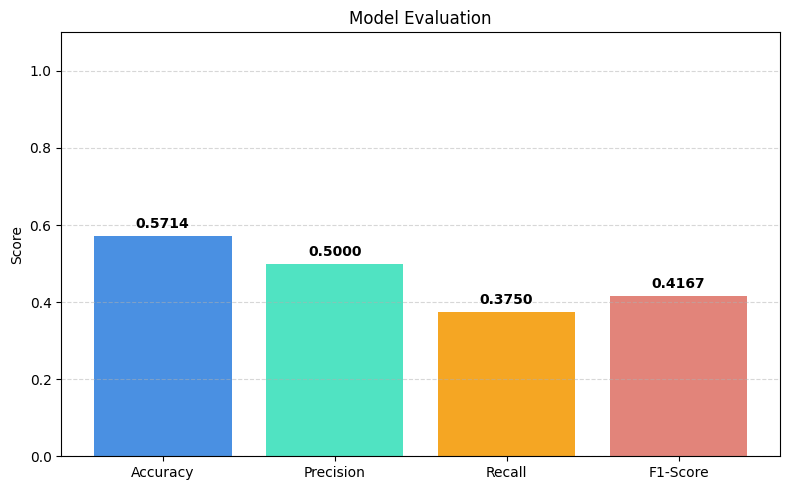

In [ ]:
# ==============================================================
# Install dependencies (Run once)
# ==============================================================
!pip install -q transformers torch scikit-learn matplotlib sentencepiece

# ==============================================================
# Imports
# ==============================================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification
)

from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score
)

# ==============================================================
# CONFIGURATION
# ==============================================================
# Change this to the folder containing your model files
MODEL_DIR = "/content/assamese_bert_ner/checkpoint-1251"

# ==============================================================
# LOAD MODEL
# ==============================================================
print(f"Loading model from: {MODEL_DIR}")

if not os.path.exists(MODEL_DIR):
    print("Current files in /content:")
    print(os.listdir("/content"))
    raise FileNotFoundError(f"Model directory '{MODEL_DIR}' not found.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model.to(device)
model.eval()

id2label = model.config.id2label
label2id = model.config.label2id

print("Labels:", list(id2label.values()))

# ==============================================================
# TEST DATA
# ==============================================================
mock_test_dataset = [
    {
        "tokens": ["ৰাহুল", "গুৱাহাটী", "বিশ্ববিদ্যালয়ত", "পঢ়ে", "।"],
        "true_tags": ["B-PER", "O", "O", "O", "O"]
    }
]

# ==============================================================
# RUN INFERENCE
# ==============================================================
all_predictions = []
all_ground_truths = []

print("\nRunning inference...")

for example in mock_test_dataset:

    tokens = example["tokens"]
    true_tags = example["true_tags"]

    true_ids = [label2id[tag] for tag in true_tags]

    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True
    )

    word_ids = encoding.word_ids(batch_index=0)

    encoding = {k: v.to(device) for k, v in encoding.items()}

    aligned_true_ids = []
    previous_word = None

    for word_id in word_ids:

        if word_id is None:
            aligned_true_ids.append(-100)

        elif word_id != previous_word:
            aligned_true_ids.append(true_ids[word_id])
            previous_word = word_id

        else:
            aligned_true_ids.append(true_ids[word_id])

    with torch.no_grad():
        outputs = model(**encoding)

    predictions = outputs.logits.argmax(dim=-1).squeeze().cpu().tolist()

    for pred, true in zip(predictions, aligned_true_ids):
        if true != -100:
            all_predictions.append(pred)
            all_ground_truths.append(true)

# ==============================================================
# METRICS
# ==============================================================
precision, recall, f1, _ = precision_recall_fscore_support(
    all_ground_truths,
    all_predictions,
    average="macro",
    zero_division=0
)

accuracy = accuracy_score(
    all_ground_truths,
    all_predictions
)

print("\n" + "="*40)
print("TEST RESULTS")
print("="*40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("="*40)

# ==============================================================
# PLOT
# ==============================================================
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))

bars = plt.bar(
    metrics_names,
    metrics_values,
    color=["#4A90E2","#50E3C2","#F5A623","#E2847A"]
)

plt.ylim(0,1.1)
plt.ylabel("Score")
plt.title("Model Evaluation")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.02,
        f"{h:.4f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig("/content/evaluation_metrics_plot.png", dpi=300)

print("\nPlot saved as: /content/evaluation_metrics_plot.png")

plt.show()


In [ ]:
# ==============================================================
# Install dependencies (Run once)
# ==============================================================
!pip install -q transformers torch sentencepiece

# ==============================================================
# Imports
# ==============================================================
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==============================================================
# MODEL PATH
# ==============================================================
# Change this to your model folder in Colab
MODEL_DIR = "/content/assamese_bert_sentiment/checkpoint-300"

# ==============================================================
# Load tokenizer and model
# ==============================================================
print("Loading model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

print("Using device:", device)

# Label mapping
id2label = model.config.id2label
print("Labels:", id2label)

# ==============================================================
# Function for sentiment prediction
# ==============================================================
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

    probabilities = torch.softmax(logits, dim=-1)[0]

    print("=" * 60)
    print("Text:")
    print(text)
    print("-" * 60)

    print("Predicted Sentiment:", id2label[prediction])
    print()

    print("Confidence Scores:")
    for i, score in enumerate(probabilities):
        print(f"{id2label[i]:15s}: {score.item():.4f}")

    print("=" * 60)


# ==============================================================
# Test Examples
# ==============================================================
texts = [
    "আজিৰ দিনটো বহুত ভাল আছিল।",
    "এই ছবিখন একেবাৰে বেয়া লাগিল।"
]

for text in texts:
    predict_sentiment(text)


Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Using device: cuda
Labels: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
Text:
আজিৰ দিনটো বহুত ভাল আছিল।
------------------------------------------------------------
Predicted Sentiment: Positive

Confidence Scores:
Negative       : 0.3127
Neutral        : 0.3080
Positive       : 0.3793
Text:
এই ছবিখন একেবাৰে বেয়া লাগিল।
------------------------------------------------------------
Predicted Sentiment: Positive

Confidence Scores:
Negative       : 0.3127
Neutral        : 0.3080
Positive       : 0.3793


It is important to note that while this IndicBERTv2 model represents an improvement over its predecessor, the
current evaluation scores indicate that it may not yet be robust enough for deployment in production-critical
applications. The primary focus of this version was to demonstrate enhanced performance compared to
version 1 and to establish a foundational benchmark for future iterations and more extensive research.